In [2]:
import pandas as pd
merged=pd.read_csv('merged.csv')

In [58]:
import pandas as pd
import numpy as np

df = pd.read_csv('merged.csv')

df['Stock_Timestamp'] = pd.to_datetime(df['Stock_Timestamp'], utc=True)
df = df.sort_values('Stock_Timestamp').reset_index(drop=True)

sentiment_map = {'positive': 1, 'neutral': 0, 'mixed': 0, 'negative': -1}
df['Sentiment_Score'] = df['Sentiment'].map(sentiment_map).fillna(0)

df['Decayed_Sentiment'] = df['Sentiment_Score'] / np.log1p(df['News_Age_Minutes'] + 1)

df['Close_to_SMA50'] = df['Close'] / df['SMA_50']
df['Close_to_EMA10'] = df['Close'] / df['EMA_10']
df['Close_to_Kalman'] = df['Close'] / df['kalman_close']

df['Vol_SMA20'] = df['Volume'].rolling(window=20).mean()
df['Relative_Volume'] = df['Volume'] / df['Vol_SMA20']

range_denom = df['rolling_high_20'] - df['rolling_low_20']
df['Price_Range_Position'] = np.where(
    range_denom == 0, 0.5, (df['Close'] - df['rolling_low_20']) / range_denom
)

minutes_since_midnight = df['Stock_Timestamp'].dt.hour * 60 + df['Stock_Timestamp'].dt.minute
day_minutes = 1440 # 24 * 60
df['Time_Sin'] = np.sin(2 * np.pi * minutes_since_midnight / day_minutes)
df['Time_Cos'] = np.cos(2 * np.pi * minutes_since_midnight / day_minutes)

df['Trans_SMA20'] = df['Transactions'].rolling(window=20).mean()
df['Relative_Transactions'] = df['Transactions'] / df['Trans_SMA20']

df['Returns_1m'] = df['Close'].pct_change()
df['Realized_Volatility'] = df['Returns_1m'].rolling(window=20).std()

df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

feature_cols = [
    'RSI_14', 'MACD_12_26_9', 'kalman_diff',    
    'Close_to_SMA50', 'Close_to_EMA10', 'Close_to_Kalman', 
    'Relative_Volume', 'Price_Range_Position',     
    'Relative_Transactions', 'Realized_Volatility',
    'Decayed_Sentiment',                           
    'Time_Sin', 'Time_Cos'                         
]

model_df = df[feature_cols + ['Target']].dropna()

print(f"Feature Engineering Complete. Final Shape: {model_df.shape}")
print(model_df.head())

Feature Engineering Complete. Final Shape: (89970, 14)
       RSI_14  MACD_12_26_9  kalman_diff  Close_to_SMA50  Close_to_EMA10  \
20  50.397598      0.103016    -0.116949        1.000782        0.999693   
21  50.062544      0.084642    -0.212878        1.000736        0.999697   
22  55.537852      0.103584     0.043101        1.001862        1.000644   
23  56.898933      0.126418     0.004952        1.002150        1.000766   
24  60.981591      0.171984     0.219202        1.003029        1.001383   

    Close_to_Kalman  Relative_Volume  Price_Range_Position  \
20         0.999703         1.212529              0.584577   
21         0.999460         1.534339              0.535135   
22         1.000109         0.865374              0.703448   
23         1.000013         0.998561              0.782759   
24         1.000555         0.950923              0.943396   

    Relative_Transactions  Realized_Volatility  Decayed_Sentiment  Time_Sin  \
20               0.818485           

In [62]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler(feature_range=(0, 1))

scaled_features = scaler.fit_transform(model_df[feature_cols])

final_data = np.column_stack((scaled_features, model_df['Target'].values))

n = len(final_data)
train_idx = int(n * 0.70)
val_idx = int(n * 0.90) 

train_data = final_data[:train_idx]
val_data = final_data[train_idx:val_idx]
test_data = final_data[val_idx:]

print(f"Train samples: {len(train_data)}")
print(f"Val samples:   {len(val_data)}")
print(f"Test samples:  {len(test_data)}")

def create_sequences(data, window_size=20):
    X, y = [], []

    for i in range(window_size, len(data)):

        X.append(data[i-window_size:i, :-1])
        
        y.append(data[i, -1])
        
    return np.array(X), np.array(y)

window_size = 20 
X_train_seq, y_train_seq = create_sequences(train_data, window_size)
X_val_seq, y_val_seq = create_sequences(val_data, window_size)
X_test_seq, y_test_seq = create_sequences(test_data, window_size)

print(f"\nFinal GRU Input Shape (X_train_seq): {X_train_seq.shape}")

Train samples: 62978
Val samples:   17995
Test samples:  8997

Final GRU Input Shape (X_train_seq): (62958, 20, 13)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

def build_stacked_gru(input_shape, lr=0.001):
    model = Sequential()
 
    model.add(Input(shape=input_shape))
    
    model.add(GRU(64, return_sequences=True))
    model.add(Dropout(0.2))
 
    model.add(GRU(32, return_sequences=False))
    model.add(Dropout(0.2))
   
    model.add(Dense(1, activation='sigmoid'))
    
    optimizer = Adam(learning_rate=lr)
    model.compile(optimizer=optimizer,
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model


input_shape = (X_train_seq.shape[1], X_train_seq.shape[2])
gru_model = build_stacked_gru(input_shape)

gru_model.summary()

history_gru = gru_model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=80,          
    batch_size=64,   
    verbose=1
)

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_15 (GRU)                    │ (None, 20, 64)         │        15,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_16 (GRU)                    │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,609 (96.13 KB)

 Trainable params: 24,609 (96.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80
984/984 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.5037 - loss: 0.6944 - val_accuracy: 0.4974 - val_loss: 0.6935
Epoch 2/80
984/984 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.5012 - loss: 0.6937 - val_accuracy: 0.5026 - val_loss: 0.6937
Epoch 3/80
984/984 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.5033 - loss: 0.6935 - val_accuracy: 0.5027 - val_loss: 0.6931
Epoch 4/80
984/984 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.4976 - loss: 0.6935 - val_accuracy: 0.5026 - val_loss: 0.6931
Epoch 5/80
984/984 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.5015 - loss: 0.6934 - val_accuracy: 0.5027 - val_loss: 0.6933
Epoch 6/80
984/984 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.5013 - loss: 0.6934 - val_accuracy: 0.5050 - val_loss: 0.6931
Epoch 7/80
984/984 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.5021 - loss: 0.6933 - val_accuracy: 0.5053 - val_loss: 0.6930
Epoch 8/80
984/984 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.5044 - loss: 0.6932 - 

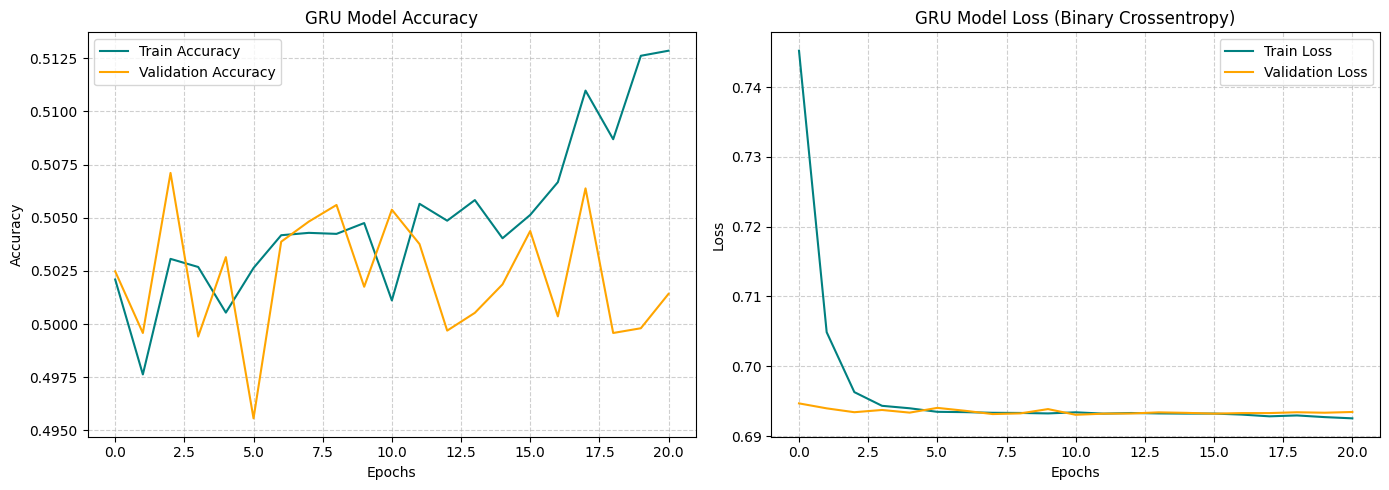

In [ ]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='Train Accuracy', color='teal')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
ax1.set_title('GRU Model Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

ax2.plot(history.history['loss'], label='Train Loss', color='teal')
ax2.plot(history.history['val_loss'], label='Validation Loss', color='orange')
ax2.set_title('GRU Model Loss (Binary Crossentropy)')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

y_pred_probs = gru_model.predict(X_test_seq)

y_pred_gru = (y_pred_probs > 0.5).astype(int)

print("--- GRU FINAL TEST RESULTS ---")
print(f"Test Accuracy: {accuracy_score(y_test_seq, y_pred_gru):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_seq, y_pred_gru))

281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
--- GRU FINAL TEST RESULTS ---
Test Accuracy: 0.6210

Classification Report:
              precision    recall  f1-score   support

         0.0       0.61      0.68      0.64      4506
         1.0       0.64      0.56      0.59      4471

    accuracy                           0.62      8977
   macro avg       0.62      0.62      0.62      8977
weighted avg       0.62      0.62      0.62      8977



       STATISTICAL PERFORMANCE (50% THRESHOLD)
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test Accuracy: 62.10%

Classification Report:
               precision    recall  f1-score   support

Down/Flat (0)       0.61      0.68      0.64      4506
       Up (1)       0.64      0.56      0.59      4471

     accuracy                           0.62      8977
    macro avg       0.62      0.62      0.62      8977
 weighted avg       0.62      0.62      0.62      8977


    FINANCIAL PERFORMANCE (>60.0% THRESHOLD)
Starting Capital:           $10,000.00
Total Trades Executed:      2069
Profitable Trades:          1398 (67.57%)

Gross Profit (Pre-Fees):    $6,356.03
Total Broker Fees Paid:     $427.74
Total Slippage Cost:        $742.10
Net Profit (Actual Money):  $5,928.29
Ending Account Equity:      $15,928.29
ROI over period:            59.28%


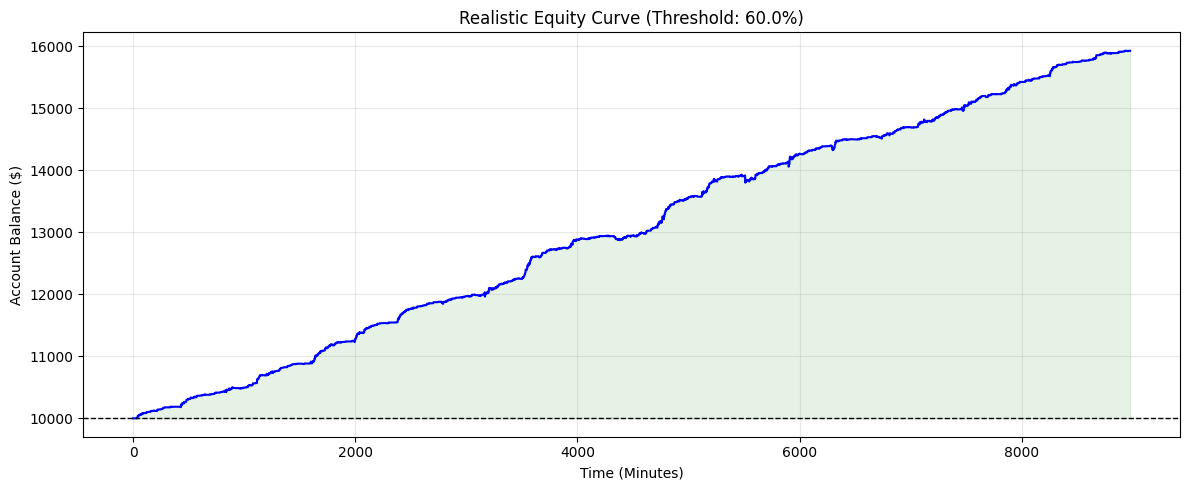

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report

print("="*50)
print("       STATISTICAL PERFORMANCE (50% THRESHOLD)")
print("="*50)

y_pred_probs = gru_model.predict(X_test_seq).flatten() 
y_pred_base = (y_pred_probs > 0.50).astype(int)

print(f"Test Accuracy: {accuracy_score(y_test_seq, y_pred_base) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test_seq, y_pred_base, target_names=['Down/Flat (0)', 'Up (1)']))


df_test = df_prices.iloc[-len(y_pred_probs):].copy()


CONFIDENCE_THRESHOLD = 0.60
df_test['Signal'] = (y_pred_probs > CONFIDENCE_THRESHOLD).astype(int)

df_test['Exec_Open'] = df_test['Open'].shift(-1)
df_test['Exec_Close'] = df_test['Close'].shift(-1)


df_test = df_test.dropna(subset=['Exec_Open', 'Exec_Close']).copy()


print("\n" + "="*50)
print(f"    FINANCIAL PERFORMANCE (>{CONFIDENCE_THRESHOLD*100}% THRESHOLD)")
print("="*50)

STARTING_CAPITAL = 10000.0
FEE_PER_SHARE = 0.009  


df_test['Slippage_Per_Share'] = (df_test['Exec_Open'] - df_test['Close'])
df_test['Total_Slippage_Cost'] = np.where(
    df_test['Signal'] == 1, 
    df_test['Slippage_Per_Share'] * np.floor(STARTING_CAPITAL / df_test['Exec_Open']), 
    0
)

df_test['Shares_Traded'] = np.where(
    df_test['Signal'] == 1, 
    np.floor(STARTING_CAPITAL / df_test['Exec_Open']), 
    0
)


df_test['Gross_PnL'] = np.where(
    df_test['Signal'] == 1, 
    (df_test['Exec_Close'] - df_test['Exec_Open']) * df_test['Shares_Traded'], 
    0
)

df_test['Fees'] = df_test['Shares_Traded'] * FEE_PER_SHARE


df_test['Net_PnL'] = df_test['Gross_PnL'] - df_test['Fees']


df_test['Equity'] = STARTING_CAPITAL + df_test['Net_PnL'].cumsum()


total_trades = df_test['Signal'].sum()
winning_trades = len(df_test[(df_test['Signal'] == 1) & (df_test['Net_PnL'] > 0)])
gross_profit = df_test['Gross_PnL'].sum()
total_fees = df_test['Fees'].sum()
total_slippage = df_test['Total_Slippage_Cost'].sum()
net_profit = df_test['Net_PnL'].sum()
final_equity = df_test['Equity'].iloc[-1]
roi = (net_profit / STARTING_CAPITAL) * 100

print(f"Starting Capital:           ${STARTING_CAPITAL:,.2f}")
print(f"Total Trades Executed:      {total_trades}")

if total_trades > 0:
    win_rate_post_fees = (winning_trades / total_trades) * 100
    print(f"Profitable Trades:          {winning_trades} ({win_rate_post_fees:.2f}%)")
else:
    print("No trades executed at this threshold.")
    
print(f"\nGross Profit (Pre-Fees):    ${gross_profit:,.2f}")
print(f"Total Broker Fees Paid:     ${total_fees:,.2f}")
print(f"Total Slippage Cost:        ${total_slippage:,.2f}")
print(f"Net Profit (Actual Money):  ${net_profit:,.2f}")
print(f"Ending Account Equity:      ${final_equity:,.2f}")
print(f"ROI over period:            {roi:.2f}%")

plt.figure(figsize=(12, 5))
plt.plot(range(len(df_test)), df_test['Equity'], color='blue', linewidth=1.5)
plt.title(f'Realistic Equity Curve (Threshold: {CONFIDENCE_THRESHOLD*100}%)')
plt.ylabel('Account Balance ($)')
plt.xlabel('Time (Minutes)')
plt.axhline(STARTING_CAPITAL, color='black', linestyle='--', linewidth=1)

plt.fill_between(range(len(df_test)), df_test['Equity'], STARTING_CAPITAL, 
                 where=(df_test['Equity'] >= STARTING_CAPITAL), color='green', alpha=0.1)
plt.fill_between(range(len(df_test)), df_test['Equity'], STARTING_CAPITAL, 
                 where=(df_test['Equity'] < STARTING_CAPITAL), color='red', alpha=0.1)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()